Hypothèse : le prix dépend du mois de vente, il y a un impact saisonnier

Dans ce notebook, nous testons l’hypothèse suivante :

> Le prix de vente des maisons dépend du mois de vente, ce qui pourrait traduire un effet saisonnier.

L’objectif est de vérifier si certaines périodes de l’année sont associées à des prix plus élevés ou plus faibles.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


df = pd.read_csv("Ames Housing.csv", sep=";", skiprows=1)

# Aperçu
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


On commence par charger le dataset Ames Housing et préparer l’environnement de visualisation.  
Comme l’objectif de l’oral est de raconter une histoire autour d’une hypothèse, on va vérifier dès le début si les variables nécessaires sont bien présentes.

Vérification des variables nécessaires

Pour tester l’hypothèse, nous avons besoin :
- d’une variable cible : `SalePrice`
- d’une variable temporelle liée au mois de vente : `Mo Sold`
- éventuellement de l’année de vente : `Yr Sold`, pour vérifier si un effet observé n’est pas simplement dû à une année particulière.

In [7]:
cols_utiles = ["SalePrice", "Mo Sold", "Yr Sold"]
print(df[cols_utiles].info())
print(df[cols_utiles].isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   SalePrice  2197 non-null   int64
 1   Mo Sold    2197 non-null   int64
 2   Yr Sold    2197 non-null   int64
dtypes: int64(3)
memory usage: 51.6 KB
None
SalePrice    0
Mo Sold      0
Yr Sold      0
dtype: int64


Cette étape est essentielle : elle montre que notre hypothèse est testable avec la base.  
Nous disposons bien du prix de vente, du mois de vente et de l’année de vente.

In [8]:
df[cols_utiles].describe(include="all")

,SalePrice,Mo Sold,Yr Sold
count,2197.000000,2197.000000,2197.000000
mean,182376.851161,6.189804,2007.793810
std,81168.157405,2.746902,1.314345
min,13100.000000,1.000000,2006.000000
25%,130000.000000,4.000000,2007.000000
50%,163500.000000,6.000000,2008.000000
75%,215000.000000,8.000000,2009.000000
max,755000.000000,12.000000,2010.000000


On vérifie aussi rapidement la structure des données avant de produire des graphiques.  
Cela permet d’anticiper d’éventuels problèmes de valeurs manquantes ou de distributions très déséquilibrées.

Reformulation analytique de l’hypothèse

Hypothèse métier :
> Le prix dépend du mois de vente.

Traduction analytique :
> La distribution de `SalePrice` varie selon `Mo Sold`.

Autrement dit, nous allons comparer les prix de vente entre les différents mois de l’année.

Cette reformulation est importante pour l’oral : elle relie directement l’idée métier aux variables du dataset.  
C’est exactement ce qui est attendu dans les consignes : une hypothèse claire, testable et liée explicitement aux variables utilisées :contentReference[oaicite:2]{index=2}.

Analyse univariée de `SalePrice`

Nous commençons par étudier la distribution du prix de vente afin de comprendre sa forme générale, sa dispersion et la présence éventuelle d’outliers.

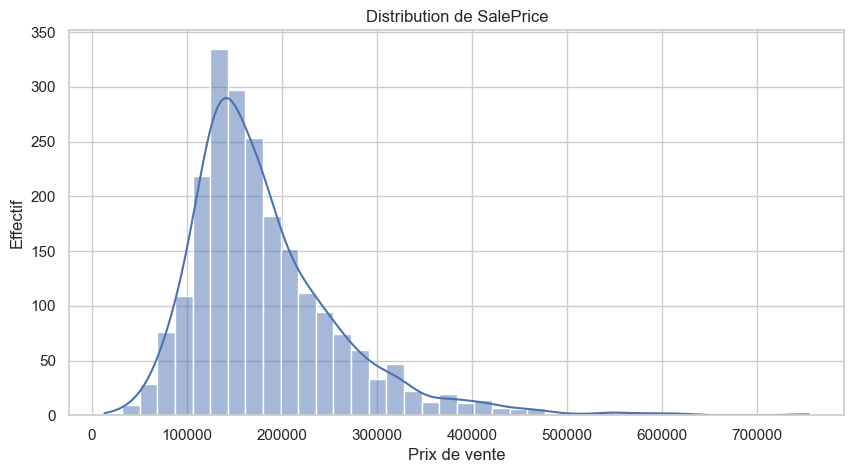

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["SalePrice"], bins=40, kde=True)
plt.title("Distribution de SalePrice")
plt.xlabel("Prix de vente")
plt.ylabel("Effectif")
plt.show()

Ce graphique permet de voir si les prix sont symétriques ou non.  
S’il y a une forte asymétrie à droite, cela pourra justifier plus tard une transformation logarithmique.

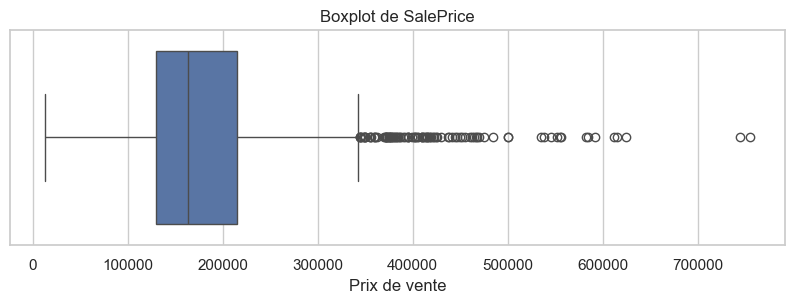

In [10]:
plt.figure(figsize=(10, 2.8))
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot de SalePrice")
plt.xlabel("Prix de vente")
plt.show()

Le boxplot complète bien l’histogramme, car il met en évidence les valeurs extrêmes.  
C’est utile pour préparer la discussion sur les limites, notamment la présence possible d’outliers.

Analyse univariée de `Mo Sold`

Nous observons maintenant la fréquence des ventes selon le mois.  
Cette étape est importante car un déséquilibre du nombre de ventes par mois peut influencer l’interprétation.

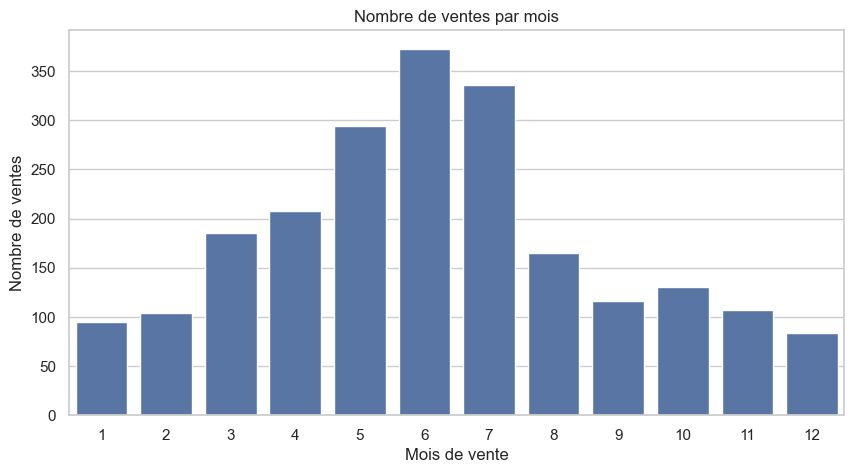

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Mo Sold", data=df, order=sorted(df["Mo Sold"].unique()))
plt.title("Nombre de ventes par mois")
plt.xlabel("Mois de vente")
plt.ylabel("Nombre de ventes")
plt.show()

Ici on voir clairement qu'il y a une augmentation des ventes à partir du printemps, avec un pique à l'été au mois de juin. 
L'hiver ne favorise clairement pas les ventes.

Relation entre le mois de vente et le prix

Pour tester directement l’hypothèse, nous comparons la distribution de `SalePrice` selon `Mo Sold`.

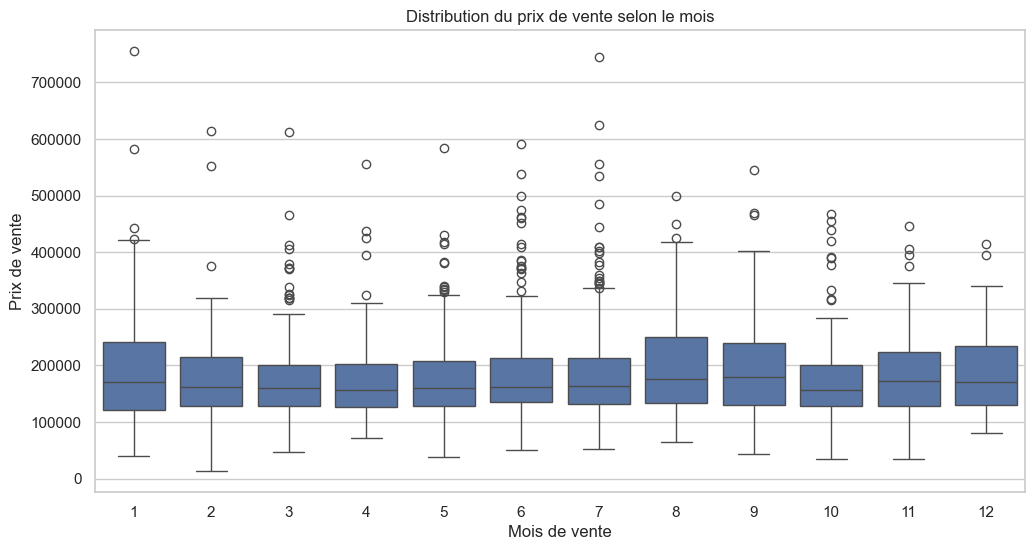

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Mo Sold", y="SalePrice", data=df, order=sorted(df["Mo Sold"].unique()))
plt.title("Distribution du prix de vente selon le mois")
plt.xlabel("Mois de vente")
plt.ylabel("Prix de vente")
plt.show()

Ce graphique est le plus adapté ici :
- `Mo Sold` est une variable discrète utilisée comme groupe,
- `SalePrice` est une variable quantitative,
- le boxplot permet de comparer la médiane, l’étendue interquartile et les valeurs extrêmes.

C’est donc le meilleur graphique pour répondre directement à l’hypothèse.

Synthèse numérique par mois

Nous calculons maintenant des indicateurs simples pour résumer les écarts entre mois :
- le nombre de ventes,
- le prix moyen,
- le prix médian.

In [13]:
resume_mois = (
    df.groupby("Mo Sold")["SalePrice"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

resume_mois

,Mo Sold,count,mean,median
0,1,95,196918.800000,170000.0
1,2,104,179200.423077,162750.0
2,3,185,176074.654054,160000.0
3,4,208,170074.250000,157450.0
4,5,294,176286.843537,160000.0
5,6,373,181689.211796,162500.0
6,7,336,184336.755952,162995.0
7,8,165,195541.442424,176485.0
8,9,116,194781.741379,180000.0
9,10,130,177699.769231,157500.0


Le prix moyen est sensible aux valeurs extrêmes, alors que la médiane est plus robuste.  
Comparer les deux permet de mieux interpréter les différences entre mois.

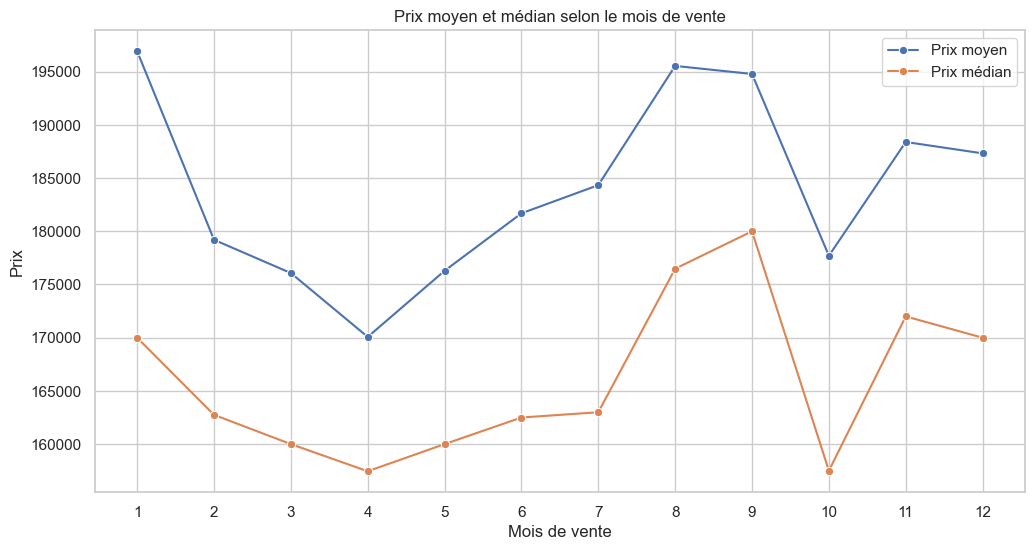

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=resume_mois, x="Mo Sold", y="mean", marker="o", label="Prix moyen")
sns.lineplot(data=resume_mois, x="Mo Sold", y="median", marker="o", label="Prix médian")
plt.title("Prix moyen et médian selon le mois de vente")
plt.xlabel("Mois de vente")
plt.ylabel("Prix")
plt.xticks(range(1, 13))
plt.show()

Ce graphique complète bien le boxplot, car il rend la tendance plus facile à lire.  
Dans nos données, les écarts existent, mais ils ne semblent pas dessiner une saisonnalité parfaitement nette et régulière sur toute l’année.